In [1]:
from IPython.core.interactiveshell import InteractiveShell
import time

old_run_cell = InteractiveShell.run_cell

def timing_run_cell(self, raw_cell, *args, **kwargs):
    t0 = time.time()
    result = old_run_cell(self, raw_cell, *args, **kwargs)
    t1 = time.time()
    print(f"Execution time: {t1 - t0:.4f} seconds")
    return result

InteractiveShell.run_cell = timing_run_cell

# Import packages

In [2]:
import scipy.interpolate as spl
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np
#import sys
from functools import partial
import os
#import pickle
import itertools
import jax
import jax.numpy as jnp
import jax.lax as lax
import jax.scipy as jsp
#import jax.extend
from multiprocessing import Pool
from jax import config
config.update("jax_enable_x64", True)
import pandas as pd
from decimal import Decimal, getcontext
import scipy.optimize as optimize
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
from matplotlib.animation import FuncAnimation, PillowWriter
import scipy.integrate as spint
from scipy.integrate import solve_ivp
from scipy.special import gammainc, gamma
from scipy.optimize import brentq
from fractions import Fraction
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
from concurrent.futures import ThreadPoolExecutor

Execution time: 3.3812 seconds


In [3]:
print(jax.devices())

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[CpuDevice(id=0)]
Execution time: 0.1714 seconds


In [4]:
BARY = pd.read_csv('../data/baryons.csv')
TOTAL = pd.read_csv('../data/galaxies_total_sample.csv')

BARY['Mass(Msun)'] =  pd.to_numeric(BARY['Mass(Msun)'], errors='coerce')
BARY['e_Mass(Msun)'] =  pd.to_numeric(BARY['e_Mass(Msun)'], errors='coerce')
BARY['j'] =  pd.to_numeric(BARY['j'], errors='coerce')
BARY['e_j'] =  pd.to_numeric(BARY['e_j'], errors='coerce')
BARY['fgas'] =  pd.to_numeric(BARY['fgas'], errors='coerce')
BARY['e_fgas'] =  pd.to_numeric(BARY['e_fgas'], errors='coerce')

TOTAL['Mstar'] =  pd.to_numeric(TOTAL['Mstar'], errors='coerce')
TOTAL['e_Mstar'] =  pd.to_numeric(TOTAL['e_Mstar'], errors='coerce')
TOTAL['Mgas'] =  pd.to_numeric(TOTAL['Mgas'], errors='coerce')
TOTAL['e_Mgas'] =  pd.to_numeric(TOTAL['e_Mgas'], errors='coerce')
TOTAL['jstar'] =  pd.to_numeric(TOTAL['jstar'], errors='coerce')
TOTAL['e_jstar'] =  pd.to_numeric(TOTAL['e_jstar'], errors='coerce')
TOTAL['jgas'] =  pd.to_numeric(TOTAL['jgas'], errors='coerce')
TOTAL['e_jgas'] =  pd.to_numeric(TOTAL['e_jgas'], errors='coerce')

obs_Mbar = np.log10(BARY['Mass(Msun)'])
obs_Mbar_errors = BARY['e_Mass(Msun)']/BARY['Mass(Msun)']
obs_Mgas = np.log10(TOTAL['Mgas'])
obs_Mgas_errors = TOTAL['e_Mgas']/TOTAL['Mgas']
obs_Mstar = np.log10(TOTAL['Mstar'])
obs_Mstar_errors = TOTAL['e_Mstar']/TOTAL['Mstar']
obs_jbar = np.log10(BARY['j'])
obs_jbar_errors = BARY['e_j']/BARY['j']
obs_jgas = np.log10(TOTAL['jgas'])
obs_jgas_errors = TOTAL['e_jgas']/TOTAL['jgas']
obs_jstar = np.log10(TOTAL['jstar'])
obs_jstar_errors = TOTAL['e_jstar']/TOTAL['jstar']
obs_fgas = np.log10(BARY['fgas'])
obs_fgas_errors = BARY['e_fgas']/BARY['fgas']
obs_fgas_but_for_stars_and_gas = TOTAL['Mgas']/(TOTAL['Mgas'] + TOTAL['Mstar'])
obs_fgas_but_for_stars_and_gas_errors = np.sqrt( (TOTAL['e_Mgas']/(TOTAL['Mgas'] + TOTAL['Mstar']))**2 + (TOTAL['Mgas']*TOTAL['e_Mstar']/((TOTAL['Mgas'] + TOTAL['Mstar'])**2))**2 )

pavel_dir = '../data/compilation_AM_others/'

pavel_data = {}

for filename in os.listdir(pavel_dir):
    if filename.endswith('.csv'):
        filepath = os.path.join(pavel_dir, filename)
        
        df = pd.read_csv(filepath)
        
        df_name = os.path.splitext(filename)[0]
        #add to superthin: 9.04,2.95,9.85,0.55,9.912537485,2.088484546,0.8658895825
        pavel_data[df_name] = df

HIX_logMstar = np.array([10.5, 10.7, 10.5, 10.5, 10.3, 10.2,  9.8, 10.1, 10.1, 10.1, 10.6, 10.5])
HIX_logMHI = np.log10(1.4 * 10**np.array([10.6, 10.7, 10.5, 10.5, 10.4, 10.3,  9.9, 10.3, 10.4, 10.3, 10.9, 10.5]))
HIX_logMbar = np.log10(10**HIX_logMstar + 10**HIX_logMHI)
HIX_fgas = (10**HIX_logMHI)/(10**HIX_logMbar)
HIX_jbar = np.array([4125.6, 3523.8, 5453.1, 4092.4, 3522.7, 3749.8, 1993. , 3196.7, 3388.2, 6377.8, 9764. , 4117.7])

Execution time: 0.0271 seconds


In [5]:
M_times1 = np.arange(0,12.2,0.1)
M_times1_jax = jnp.array(M_times1, dtype=jnp.float64)
log_M_bar_array = np.linspace(8,11.5,50)
dt = 0.1
N = 1.4
A = 0.1625
Rf = 0.3

t_end = float(M_times1[-1])
n_t = M_times1_jax.shape[0]
log_M_bar_array_jax = jnp.array(log_M_bar_array, dtype=jnp.float64)

Execution time: 0.0366 seconds


In [ ]:
def RungeKutta(x, y, dx, dydx):
    # Calculate slopes
    k1 = dx * dydx(x, y)
    k2 = dx * dydx(x + dx / 2., y + k1 / 2.)
    k3 = dx * dydx(x + dx / 2., y + k2 / 2.)
    k4 = dx * dydx(x + dx, y + k3)
    
    # Calculate new x and y
    y_new = y + (1. / 6.) * (k1 + 2 * k2 + 2 * k3 + k4)
    x_new = x + dx
    
    return x_new, y_new

def Sigma_definer(r, r_acc, t_acc, C):
    """
    Defines the gas surface density 2D array M_sigma(r, t).

    r      : 1D radius array (pc)
    r_acc  : scalar accretion scale length (pc)
    t_acc  : scalar accretion timescale (Gyr)
    C      : normalization constant to reach desired M_bar at t0
    """
    n_r = len(r)
    n_t = len(M_times1)
    M_sigma = np.zeros((n_r, n_t))

    # assume M_times1 is monotonically increasing with constant spacing dt
    dt_local = M_times1[1] - M_times1[0]
    t_end = M_times1[-1]

    for i, r_value in enumerate(r):
        def dydx(t, S):
            # accretion term - KS consumption term
            acc = (C / (2.0 * np.pi * (r_acc**2))) * np.exp(-t / t_acc) * np.exp(-r_value / r_acc)
            sfr = SFL(S)
            return acc - sfr

        # initial conditions
        t = 0.0
        S = 0.0
        S_row = np.zeros(n_t)
        S_row[0] = S

        # integrate forward in time following M_times1 grid
        for j in range(1, n_t):
            t, S = RungeKutta(t, S, dt_local, dydx)
            S_row[j] = S

        M_sigma[i, :] = S_row

    return M_sigma


def SFL(sigma, sfl_type='old_ksl'):
    Rf = 0.3
    sigma_arr = np.asarray(sigma, dtype=float)

    # Enforce physical domain: negative gas is set 0
    sigma_pos = np.where(sigma_arr > 0.0, sigma_arr, 0.0)

    if sfl_type == "old_ksl":
        N = 1.4
        A = 0.1625
        SFL_val = (1 - Rf) * A * (sigma_pos**N)

    elif sfl_type == "new_ksl":
        A_ksl = 5.18e-4
        N_ksl = 3.83
        SFL_val = (1 - Rf) * A_ksl * (sigma_pos**N_ksl)

    elif sfl_type == "cutoff_ksl":
        thr = 1.0239163123543726

        with np.errstate(divide='ignore', invalid='ignore'):
            log_sigma = np.where(sigma_pos > 0.0, np.log10(sigma_pos), -np.inf)

        mask = log_sigma < thr

        low_reg  = (1 - Rf) * 5.20e-4 * (sigma_pos**3.83)
        high_reg = (1 - Rf) * 0.1625   * (sigma_pos**1.4)

        SFL_val = np.where(mask, low_reg, high_reg)

    else:
        raise ValueError(f"Unknown sfl_type: {sfl_type}")

    SFL_val = np.where(np.isfinite(SFL_val), SFL_val, 0.0)

    if np.isscalar(sigma):
        return float(SFL_val)
    return SFL_val

def SFL_jax(sigma, sfl_type, R, Mbar):
    Rf = 0.3
    if sfl_type == "old_ksl":
        N = 1.4
        A = 0.1625
        return (1.0 - Rf) * A * (sigma**N)
    elif sfl_type == "new_ksl":
        A_ksl = 5.18e-4
        N_ksl = 3.83
        return (1.0 - Rf) * A_ksl * (sigma**N_ksl)
    elif sfl_type == "cutoff_ksl":
        # piecewise, same as your cutoff KSL
        log_sigma = jnp.log10(jnp.clip(sigma, a_min=1e-99))  # just to avoid log(0), not a floor on sigma itself
        A1, N1 = 5.20e-4, 3.83
        A2, N2 = 0.1625,  1.4
        cond = log_sigma < 1.0239163123543726
        sfl1 = (1.0 - Rf) * A1 * (sigma**N1)
        sfl2 = (1.0 - Rf) * A2 * (sigma**N2)
        return jnp.where(cond, sfl1, sfl2)
    else:
        raise ValueError(f"Unknown sfl_type '{sfl_type}' in SFL_jax")

def v_btfr_def(M_bar, Ag=47):
    """Returns the value of the velocity from the baryonic Tully-Fisher relation. The default constant
    value Ag is taken from McGaugh (2012)."""
    return (M_bar/Ag)**0.25

def rv_def(M_bar, kpc=True):
    if kpc:
        return -0.005034150233993362*v_btfr_def(M_bar)+2.6658196850679956
    else:
        return -5.034150233993362*v_btfr_def(M_bar)+2665.8196850679956
    
def exp_vrot(r, Mbar, kpc=False):
    rv = rv_def(Mbar, kpc=kpc)
    return v_btfr_def(Mbar)*(1-np.exp(-r/rv))

def exp_vrot_jax(r_pc, M_bar):
    rv = rv_def(M_bar, kpc=False)
    return v_btfr_def(M_bar) * (1.0 - jnp.exp(-r_pc / rv))

def analytical_r(x, c, y):
    return x - (c**3 * x) / (c + x)**3 - y
    
def j_maxer(Mbar):
    """Same as your j_maxer, but numpy version for precomputation."""
    return (Mbar**0.73) * 10.0**(-4.25)

def r_btfr_def(M_bar, j_acc, init=1.0):
    """Returns r_acc in kpc (numpy, uses root finding)."""
    rv = rv_def(M_bar, kpc=True)
    yer = j_acc / (2.0 * v_btfr_def(M_bar))
    return optimize.newton(analytical_r, init, args=(rv, yer))

def build_r_acc_grid_for_all_M(log_M_bar_array, n_j=10):
    """
    For each Mbar in log_M_bar_array, build an array of n_j constant r_acc values
    corresponding to j_acc spanning [j_min, j_max].

    Returns: r_acc_grid_pc with shape (n_M, n_j) in pc.
    """
    n_M = len(log_M_bar_array)
    r_acc_grid_pc = np.zeros((n_M, n_j), dtype=float)

    for i, logM in enumerate(log_M_bar_array):
        Mbar = 10.0**logM
        j_max = j_maxer(Mbar)
        j_min = j_max / 10.0
        j_acc_array = np.linspace(j_min, j_max, n_j)

        r_acc_list = []
        for j_acc in j_acc_array:
            r_kpc = r_btfr_def(Mbar, j_acc) # kpc
            r_acc_list.append(1000.0*r_kpc) # pc

        r_acc_grid_pc[i, :] = np.array(r_acc_list, dtype=float)

    return r_acc_grid_pc

Execution time: 0.0085 seconds


In [7]:
# build once
r_acc_grid_np = build_r_acc_grid_for_all_M(log_M_bar_array, n_j=10)
r_acc_grid_jax = jnp.array(r_acc_grid_np, dtype=jnp.float64)

Execution time: 0.0683 seconds


In [8]:
def sigma_acc_const_jax(t, r_value, C, t_acc, r_acc_pc):
    """
    Accretion surface density with constant r_acc (in pc).
    """
    return (C / (2.0 * jnp.pi * r_acc_pc**2.0)) * \
           jnp.exp(-t / t_acc) * jnp.exp(-r_value / r_acc_pc)


def choose_dt_const_jax(t, S, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc,
                        base_dt=0.1, dt_min=1e-3, safety=2.0):
    """
    Adaptive dt, same logic as your good model, but with constant r_acc.
    """
    S = jnp.asarray(S)

    Sigma_acc = sigma_acc_const_jax(t, r_value, C, t_acc, r_acc_pc)
    Sigma_sfr = SFL_jax(S, sfl_type, r_value, M_bar)

    t_sup = jnp.where((S > 0.0) & (Sigma_acc > 0.0), S / Sigma_acc, jnp.inf)
    t_dep = jnp.where((S > 0.0) & (Sigma_sfr > 0.0), S / Sigma_sfr, jnp.inf)

    t_char = jnp.minimum(t_sup, t_dep)
    dt_raw = jnp.minimum(base_dt, t_char / safety)
    dt_raw = jnp.maximum(dt_raw, dt_min)

    dt = jnp.where(S <= 0.0, base_dt, dt_raw)
    return dt


def dydt_const_jax(t, S, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc):
    Sigma_acc = sigma_acc_const_jax(t, r_value, C, t_acc, r_acc_pc)
    Sigma_sfr = SFL_jax(S, sfl_type, r_value, M_bar)
    return Sigma_acc - Sigma_sfr


def RungeKutta_const_jax(t, S, dt, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc):
    k1 = dydt_const_jax(t,            S,             r_value, C, t_acc, M_bar, sfl_type, r_acc_pc)
    k2 = dydt_const_jax(t + 0.5*dt,   S + 0.5*dt*k1, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc)
    k3 = dydt_const_jax(t + 0.5*dt,   S + 0.5*dt*k2, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc)
    k4 = dydt_const_jax(t + dt,       S + dt*k3,     r_value, C, t_acc, M_bar, sfl_type, r_acc_pc)

    S_new = S + (dt / 6.0) * (k1 + 2.0*k2 + 2.0*k3 + k4)
    t_new = t + dt
    S_new = jnp.maximum(S_new, 0.0)
    return t_new, S_new

@partial(jax.jit, static_argnames=("sfl_type",))
def compute_row_static_racc_jax(r_value, M_bar, C, t_acc, sfl_type, r_acc_pc):
    """
    Solve Σ_gas(t) at one radius r_value for a model with:
      - fixed r_acc (r_acc_pc),
      - given M_bar, C, t_acc,
      - star formation law sfl_type (use "cutoff_ksl").

    Returns: Σ_gas(t_j) on M_times1_jax grid, shape (n_t,)
    """
    t0 = 0.0
    S0 = 0.0
    row0 = jnp.zeros(n_t, dtype=jnp.float64).at[0].set(S0)
    save_idx0 = 1

    state0 = (t0, S0, save_idx0, row0)

    def cond_fun(state):
        t, S, save_idx, row = state
        return jnp.logical_and(t < t_end, save_idx < n_t)

    def body_fun(state):
        t, S, save_idx, row = state

        dt_loc = choose_dt_const_jax(
            t, S, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc,
            base_dt=0.1, dt_min=1e-3, safety=2.0
        )

        t_new, S_new = RungeKutta_const_jax(
            t, S, dt_loc, r_value, C, t_acc, M_bar, sfl_type, r_acc_pc
        )

        carry = (t, S, t_new, S_new, save_idx, row)

        def save_branch(c):
            t_old, S_old, t_n, S_n, idx, row_i = c
            t_grid = M_times1_jax[idx]
            denom = jnp.maximum(t_n - t_old, 1e-12)
            theta = (t_grid - t_old) / denom
            S_grid = S_old + theta * (S_n - S_old)
            row_i = row_i.at[idx].set(S_grid)
            return (t_n, S_n, t_n, S_n, idx + 1, row_i)

        def nosave_branch(c):
            t_old, S_old, t_n, S_n, idx, row_i = c
            return (t_n, S_n, t_n, S_n, idx, row_i)

        cond_save = jnp.logical_and(
            save_idx < n_t,
            t_new >= M_times1_jax[save_idx]
        )

        t2, S2, _t2, _S2, save_idx2, row2 = lax.cond(
            cond_save, save_branch, nosave_branch, carry
        )
        return (t2, S2, save_idx2, row2)

    t_f, S_f, save_idx_f, row_f = lax.while_loop(cond_fun, body_fun, state0)

    # Fill remainder with last value if we stopped early
    def fill_rest(row):
        last_val = row[save_idx_f - 1]
        idxs = jnp.arange(n_t)
        mask = idxs >= save_idx_f
        return jnp.where(mask, last_val, row)

    row_f = lax.cond(save_idx_f < n_t, fill_rest, lambda x: x, row_f)
    return row_f

@partial(jax.jit, static_argnames=("sfl_type",))
def Sigma_definer_static_racc_jax(r_pc, t_acc, M_bar, C, sfl_type, r_acc_array_pc):
    """
    JAX equivalent of Sigma_definer for the 'bad' model:
    - r_acc_array_pc: (n_racc,) constant accretion radii in pc
    Returns:
      SD_gas of shape (n_racc, n_r, n_t)
    """
    r_pc = jnp.asarray(r_pc, dtype=jnp.float64)

    def Sigma_for_one_racc(r_acc_pc):
        def solve_at_radius(r_value):
            return compute_row_static_racc_jax(r_value, M_bar, C, t_acc,
                                               sfl_type, r_acc_pc)
        # Σ_gas(R, t) for this r_acc
        return jax.vmap(solve_at_radius)(r_pc)  # (n_r, n_t)

    SD_gas = jax.vmap(Sigma_for_one_racc)(r_acc_array_pc)  # (n_racc, n_r, n_t)
    return SD_gas

Execution time: 0.0075 seconds


In [9]:
def Full_final_definer(Mbar, t_acc, res=120, Rmax=100.1, at_t0=True, SFL_type="old_ksl"):
    """
    Defines the global fraction of gas and baryonic specific angular momentum arrays.
    This function is self-contained; together with the Sigma_definer function, and the functions defining 
    the accretion radius and angular momentum, as well as the baryonic mass and rotational velocity, it 
    alone should give the arrays for the final FINAL graph.
    
    --------------
    Inputs:
        - Mbar (float)           --> Baryonic mass value for which you want to evaluate global gas fraction and 
                                     (specific) angular momentum.
        - t_acc (float)          --> Accretion timescale value. This function now works 
                                     for any number of values within the array!
        - res (float)            --> (optional) Resolution of the radius array; gives the values of the radii at
                                     which values are evaluated. Default is 120 pc.
        - Rmax (float)           --> (optional) Maximum radius to evaluate. Default is 100.1 kpc. Together with
                                     res these defaults were chosen as to optimize run time and convergence of 
                                     specific angular momentum. 
        - at_t0 (bool)           --> (optional) Specifes whether to return just the values today (True), or the 
                                     entire evolution (False). Default is True.
    
    Returns:
        - f_gas_array (np.array) --> Array containing, depending on at_t0, either the values of the global
                                     gas fraction today (t = 12Gyr), or in the entire evolution.
        - j_bar_array (np.array) --> Array containing, depending on at_t0, either the values of the specific
                                     angular momentum today (t = 12Gyr), or in the entire evolution.
    
    """
    
    r = np.arange(0,1000*Rmax,res)
    dr = res
    #Mbar_full = np.full(M_times1.shape, Mbar)
    j_max = (Mbar**0.73)*10**(-4.25)
    j_min = j_max/10
    j_acc_array = np.linspace(j_min, j_max, 10)
    
    r_acc_array = np.zeros(len(j_acc_array))
    for i in range(len(j_acc_array)):
        r_acc_array[i] = 1000*r_btfr_def(Mbar, j_acc_array[i])
    C_c = Mbar/(t_acc*(1-np.exp(-12/t_acc)))
    
    SD_gas = np.array([Sigma_definer(r, r_acc, t_acc, C_c) for r_acc in r_acc_array])
    SD_sfr = np.array([SFL(SD_gas[i], sfl_type=SFL_type) for i in range(len(SD_gas))])
    
    r = r.reshape(len(r),1)
    
    M_gas = np.array([2*np.pi*spint.simpson(r*SD_gas[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    M_sfr = np.array([2*np.pi*spint.simpson(r*SD_sfr[i], dx=dr, axis=0) for i in range(len(SD_gas))])
    M_star = np.array([dt*np.cumsum(M_sfr[i]) for i in range(len(SD_gas))])
    M_bar = np.array([np.array([np.sum(x) for x in zip(M_star[i], M_gas[i])]) for i in range(len(SD_gas))])
    f_gas_global = np.array([np.divide(M_gas[i], M_bar[i]) for i in range(len(SD_gas))])

    #Mbar_allsame = np.full(len(M_bar[0]), M_bar[0][-1])
    #v_rot = v_btfr_def(Mbar_allsame[0])
    
    nominator_gas = np.array([2*np.pi*spint.simpson(r**2*SD_gas[i]*exp_vrot(r, Mbar), dx=dr, axis=0) for i in range(len(SD_gas))])
    nominator_sfr = np.array([2*np.pi*spint.simpson(r**2*SD_sfr[i]*exp_vrot(r, Mbar), dx=dr, axis=0) for i in range(len(SD_gas))])
    nominator_star = np.array([dt*np.cumsum(nominator_sfr[i]) for i in range(len(SD_gas))])
    nominator_bar = np.array([np.array([np.sum(x) for x in zip(nominator_star[i], nominator_gas[i])]) for i in range(len(SD_gas))])
    j_bar = np.array([np.divide(nominator_bar[i], M_bar[i]) for i in range(len(SD_gas))])
    j_gas = np.array([np.divide(nominator_gas[i], M_gas[i]) for i in range(len(SD_gas))])
    j_star = np.array([np.divide(nominator_star[i], M_star[i]) for i in range(len(SD_gas))])
    
    M_star_t0 = M_star[:,-1]
    M_gas_t0  = M_gas[:,-1]
    
    if (at_t0==True):
        f_gas_array = f_gas_global[:,-1]
        j_bar_array = j_bar[:,-1]/1000
        j_gas_array = j_gas[:,-1]/1000
        j_star_array = j_star[:,-1]/1000
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star_t0, M_gas_t0
    else:
        f_gas_array = f_gas_global
        j_bar_array = j_bar/1000
        j_gas_array = j_gas/1000
        j_star_array = j_star/1000
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star, M_gas

def process_mbar(M, t_acc, *args):
    """
    Implements multiprocessing
    """
    return Full_final_definer(10**M, t_acc, *args)

def simpson_uniform_jax(y, dx, axis=0):
    """
    Simpson integration with uniform spacing dx in JAX.
    Handles both even and odd number of samples like scipy.integrate.simpson:
      - if N points => N-1 intervals
      - if (N-1) is odd (N even): Simpson on first N-1 points, trapezoid for last interval.
    """
    y = jnp.asarray(y)
    # move integration axis to 0 for convenience
    y = jnp.moveaxis(y, axis, 0)

    N = y.shape[0]

    # if N < 2, integral is zero
    if N < 2:
        return jnp.zeros_like(y[0])

    def simpson_all(y_local):
        w = jnp.ones(N)
        w = w.at[1:N-1:2].set(4.0)
        w = w.at[2:N-1:2].set(2.0)
        return dx / 3.0 * jnp.tensordot(w, y_local, axes=(0, 0))

    def simpson_plus_trap(y_local):
        # use Simpson on first N-1 points, trap on last interval
        Nsim = N - 1
        y_s = y_local[:Nsim] # Simpson part
        w = jnp.ones(Nsim)
        w = w.at[1:Nsim-1:2].set(4.0)
        w = w.at[2:Nsim-1:2].set(2.0)
        simp = dx / 3.0 * jnp.tensordot(w, y_s, axes=(0, 0))
        trap = dx * 0.5 * (y_local[-2] + y_local[-1])
        return simp + trap

    result = jax.lax.cond(
        (N % 2 == 1),
        simpson_all,
        simpson_plus_trap,
        y
    )

    return jnp.moveaxis(result, 0, axis)

@partial(jax.jit, static_argnames=("star_formation_law", "at_t0"))
def full_from_sigma_jax(SD_gas, Mbar, r_pc, dt, star_formation_law, at_t0=True):
    """
    SD_gas: (n_tacc, n_r, n_t)  Σ_gas in Msun/pc^2
    r_pc:   (n_r,) radii in pc
    dt:     scalar time step between entries in M_times1 (Gyr)
    Mbar:   scalar baryonic mass (Msun)

    Returns same outputs as your Full_final_definer (with /1000 for j).
    """
    SD_gas = jnp.asarray(SD_gas)
    r_pc = jnp.asarray(r_pc)
    dr = r_pc[1] - r_pc[0]

    n_tacc, n_r, n_t = SD_gas.shape

    r_col = r_pc[:, None]
    r2_col = r_col**2

    if star_formation_law != "cutoff_ksl":
        raise ValueError("full_from_sigma_jax currently implemented only for 'cutoff_ksl'.")

    # broadcast R just to satisfy the signature; it’s ignored for cutoff_ksl
    R_broad = r_col[None, :, :] # (1, n_r, 1) -> broadcasts to SD_gas
    Sigma_sfr = SFL_jax(SD_gas, "cutoff_ksl", R_broad, Mbar)  # (n_tacc, n_r, n_t)

    integrand_gas = r_col[None, :, :]*SD_gas
    integrand_sfr = r_col[None, :, :]*Sigma_sfr

    def integrate_radius(y):
        return 2.0 * jnp.pi * simpson_uniform_jax(y, dr, axis=0)

    M_gas = jax.vmap(integrate_radius)(integrand_gas)  
    M_sfr = jax.vmap(integrate_radius)(integrand_sfr)  

    M_star = dt*jnp.cumsum(M_sfr, axis=-1)           
    M_bar_tot = M_star + M_gas

    f_gas_global = M_gas / M_bar_tot                   

    v_rot = exp_vrot_jax(r_pc, Mbar)[:, None]
    integrand_gas_j = r2_col[None,:,:]*SD_gas*v_rot[None, :, :]
    integrand_sfr_j = r2_col[None,:,:]*Sigma_sfr*v_rot[None, :, :]

    def integrate_radius_j(y):
        return 2.0 * jnp.pi * simpson_uniform_jax(y, dr, axis=0)

    nom_gas  = jax.vmap(integrate_radius_j)(integrand_gas_j)
    nom_sfr  = jax.vmap(integrate_radius_j)(integrand_sfr_j)
    nom_star = dt * jnp.cumsum(nom_sfr, axis=-1)
    nom_bar  = nom_star + nom_gas

    j_bar  = nom_bar / jnp.where(M_bar_tot > 0, M_bar_tot, jnp.inf)
    j_gas  = nom_gas/ jnp.where(M_gas > 0, M_gas, jnp.inf)
    j_star = nom_star / jnp.where(M_star > 0, M_star, jnp.inf)

    if at_t0:
        f_gas_array  = f_gas_global[:, -1]
        j_bar_array  = j_bar[:, -1]/1000.0
        j_gas_array  = j_gas[:, -1]/1000.0
        j_star_array = j_star[:, -1]/1000.0
        M_star_t0    = M_star[:, -1]
        M_gas_t0     = M_gas[:, -1]
        return f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star_t0, M_gas_t0
    else:
        return (f_gas_global,
                j_bar  / 1000.0,
                j_gas  / 1000.0,
                j_star / 1000.0,
                M_star,
                M_gas)

def C_def_jax(M_bar, t_acc, t0=12.0):
    """
    JAX-friendly version of C_def.
    """
    t_acc = jnp.asarray(t_acc, dtype=jnp.float64)

    pos = t_acc > 0.0
    neg = t_acc < 0.0
    infmask = jnp.isinf(t_acc)

    # positive t_acc
    C_pos = M_bar / (t_acc * (1.0 - jnp.exp(-t0 / t_acc)))

    # negative t_acc
    abs_t = jnp.abs(t_acc)
    C_neg = M_bar / (abs_t * (jnp.exp(t0 / abs_t) - 1.0))

    # infinite t_acc
    C_inf = M_bar / t0

    C = jnp.where(pos, C_pos, C_neg)
    C = jnp.where(infmask, C_inf, C)

    return C

@partial(jax.jit,
         static_argnames=("star_formation_law", "res", "Rmax", "at_t0"))
def Full_final_definer_bad_jax(Mbar,
                               t_acc,
                               star_formation_law,
                               r_acc_array_for_M_pc,
                               res=120,
                               Rmax=100.1,
                               at_t0=True):
    """
    JAX 'bad' model for a single Mbar and single t_acc:
    - Mbar: scalar Msun
    - t_acc: scalar Gyr
    - r_acc_array_for_M_pc: (n_racc,) in pc (constant in time)
    - star_formation_law: e.g. 'cutoff_ksl'
    Returns:
      f_gas_array, j_bar_array, j_gas_array, j_star_array, M_star_t0, M_gas_t0
      each of shape (n_racc,)
    """
    # radius grid in pc
    r_pc = jnp.arange(0.0, 1000.0*Rmax, res, dtype=jnp.float64)

    # normalization for this t_acc
    C_val = C_def_jax(Mbar, t_acc)  # scalar

    # Σ_gas(r, t) for each r_acc
    SD_gas = Sigma_definer_static_racc_jax(
        r_pc,
        t_acc,
        Mbar,
        C_val,
        star_formation_law,
        r_acc_array_for_M_pc
    )  # (n_racc, n_r, n_t)

    # post-process: full_from_sigma_jax expects (n_batch, n_r, n_t)
    return full_from_sigma_jax(
        SD_gas,
        Mbar,
        r_pc,
        dt,
        star_formation_law,
        at_t0=at_t0,
    )
    
@partial(jax.jit,
         static_argnames=("star_formation_law", "res", "Rmax", "at_t0"))
def run_all_masses_bad_jax(Mbar_grid,
                           t_acc_array,
                           r_acc_grid_pc,
                           star_formation_law="cutoff_ksl",
                           res=120,
                           Rmax=100.1,
                           at_t0=True):
    """
    JAX driver for the 'bad' model:
      Mbar_grid : (n_M,)
      t_acc_array : (n_tacc,)
      r_acc_grid_pc : (n_M, n_racc)
    Returns:
      f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all
      each of shape (n_M, n_tacc, n_racc)
    """

    def per_mass(Mbar, r_acc_row):
        # for this mass, vmap over t_acc
        def per_tacc(t_acc):
            return Full_final_definer_bad_jax(
                Mbar,
                t_acc,
                star_formation_law,
                r_acc_row,
                res=res,
                Rmax=Rmax,
                at_t0=at_t0,
            )
        # each is (n_racc,)
        f_gas_mt, j_bar_mt, j_gas_mt, j_star_mt, Ms_mt, Mg_mt = \
            jax.vmap(per_tacc)(t_acc_array)  # (n_tacc, n_racc)
        return f_gas_mt, j_bar_mt, j_gas_mt, j_star_mt, Ms_mt, Mg_mt

    f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all = \
        jax.vmap(per_mass)(Mbar_grid, r_acc_grid_pc)
    # shapes: (n_M, n_tacc, n_racc)

    return f_gas_all, j_bar_all, j_gas_all, j_star_all, Ms_all, Mg_all

def modelled_j_bar2(f_gas_array, j_bar_array, f_gas_value, kind=1):
    """
    The function takes as input the arrays for f_gas and j_bar (possibly already interpolated), 
    together with a wanted value of f_gas for which to slice out the 1D array. 
    
    ------------
    Inputs:
    - f_gas_array = interpolated 2D array of f_gas
    - j_bar_array = interpolated 2D array of j_bar
    - f_gas_value = value of f_gas for which to slice the f_gas/j_bar arrays
    - kind = Inerpolation type (default is 1 - linear)
    
    The function does the following
    - Creates a list 'index_array', which has the indexes of constant f_gas_value chosen as elements.
    - Then, it iteratively takes from the j_bar_array the values corresponding to the indexes from index_array
    - Finally it interpolates the indexed j_bar_array through the M_bar_array, to get a plottable linear function.
    
    Returns:
    - indexed_M_array_lin = A simple linspace with the initial and final values of the original log_M_bar_array
    """
    indexed_j_array = []
    index_array = []
    true_list = []
    
    for i in range(len(log_M_bar_array)):
        if f_gas_value>np.min(f_gas_array[i]) and f_gas_value<np.max(f_gas_array[i]):
            index_array.append(np.argwhere(f_gas_array[i] == min(f_gas_array[i], key=lambda x:abs(x-f_gas_value))))
            true_list.append(1)
        else:
            index_array.append(0)
            true_list.append(0)
    
    j = 0
    while (j<50):
        if (true_list[j]==1):
            indexed_j_array.append(j_bar_array[j][index_array[j]])
        j += 1
    
    if len(indexed_j_array)>kind:
        index = np.argwhere(np.array(true_list) == 1)
        indexed_M_array = log_M_bar_array[index]
        indexed_M_array_lin = np.linspace(indexed_M_array[0], indexed_M_array[-1], 1000)
        interpolation = spl.InterpolatedUnivariateSpline(indexed_M_array.reshape(len(indexed_M_array),), indexed_j_array, k=kind)
        interpolated_j_array = interpolation(indexed_M_array_lin).reshape(len(indexed_M_array_lin),)
    else:
        indexed_M_array_lin = []
        interpolated_j_array = []
    
    return indexed_M_array_lin, interpolated_j_array

Execution time: 0.0156 seconds


t_acc_array = np.array([3., 10., 25.]) # Gyr
n_M = len(log_M_bar_array)
n_tac = len(t_acc_array)

# Arrays: first index = mass, second index = t_acc
f_gas_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
j_bar_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
j_gas_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
j_star_array_10_50_cutoff_ksl = np.zeros((n_M, n_tac, 10))
Mstar_grid = np.zeros((n_M, n_tac, 10))
Mgas_grid  = np.zeros((n_M, n_tac, 10))

for j_tac, t_acc in enumerate(t_acc_array):
    print(f"Running models for t_acc = {t_acc:.1f} Gyr")

    # process_mbar takes (M, t_acc)
    process_mbar_cutoff_ksl = partial(process_mbar, t_acc=t_acc)

    # parallelize over M for this fixed t_acc
    with ProcessPoolExecutor() as executor:
        results = list(executor.map(process_mbar_cutoff_ksl, log_M_bar_array))

    # unpack results into [:, j_tac, :]
    for i_M, (f_gas_temp, j_bar_temp, j_gas_temp, j_star_temp,
              Ms_temp,   Mg_temp) in enumerate(results):

        f_gas_array_10_50_cutoff_ksl[i_M, j_tac, :] = f_gas_temp
        j_bar_array_10_50_cutoff_ksl[i_M, j_tac, :] = j_bar_temp
        j_gas_array_10_50_cutoff_ksl[i_M, j_tac, :] = j_gas_temp
        j_star_array_10_50_cutoff_ksl[i_M, j_tac, :] = j_star_temp
        Mstar_grid[i_M, j_tac, :] = Ms_temp
        Mgas_grid[i_M, j_tac, :] = Mg_temp

np.save('../data/data_elise_new_rot/final_f_gas_cutoff_ksl.npy', f_gas_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_bar_cutoff_ksl.npy', j_bar_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_gas_cutoff_ksl.npy', j_gas_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_star_cutoff_ksl.npy', j_star_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_Mstar_grid_cutoff_ksl.npy', Mstar_grid)
np.save('../data/data_elise_new_rot/final_Mgas_grid_cutoff_ksl.npy', Mgas_grid)

In [21]:
t_acc_array = np.array([3.0, 10.0, 25.0, -10.0], dtype=float)
t_acc_array_jax = jnp.array(t_acc_array, dtype=jnp.float64)

Mbar_grid = 10.0**log_M_bar_array
Mbar_grid_jax = jnp.array(Mbar_grid, dtype=jnp.float64)

f_gas_all_jax, j_bar_all_jax, j_gas_all_jax, j_star_all_jax, Ms_all_jax, Mg_all_jax = \
    run_all_masses_bad_jax(
        Mbar_grid_jax,
        t_acc_array_jax,
        r_acc_grid_jax,
        star_formation_law="cutoff_ksl",
    )

f_gas_array_10_50_cutoff_ksl = np.array(f_gas_all_jax)
j_bar_array_10_50_cutoff_ksl = np.array(j_bar_all_jax)
j_gas_array_10_50_cutoff_ksl = np.array(j_gas_all_jax)
j_star_array_10_50_cutoff_ksl = np.array(j_star_all_jax)
Mstar_grid = np.array(Ms_all_jax)
Mgas_grid  = np.array(Mg_all_jax)

np.save('../data/data_elise_new_rot/final_f_gas_cutoff_ksl_bad_jax.npy', f_gas_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_bar_cutoff_ksl_bad_jax.npy', j_bar_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_gas_cutoff_ksl_bad_jax.npy', j_gas_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_j_star_cutoff_ksl_bad_jax.npy', j_star_array_10_50_cutoff_ksl)
np.save('../data/data_elise_new_rot/final_Mstar_grid_cutoff_ksl_bad_jax.npy', Mstar_grid)
np.save('../data/data_elise_new_rot/final_Mgas_grid_cutoff_ksl_bad_jax.npy', Mgas_grid)

Execution time: 51.9397 seconds


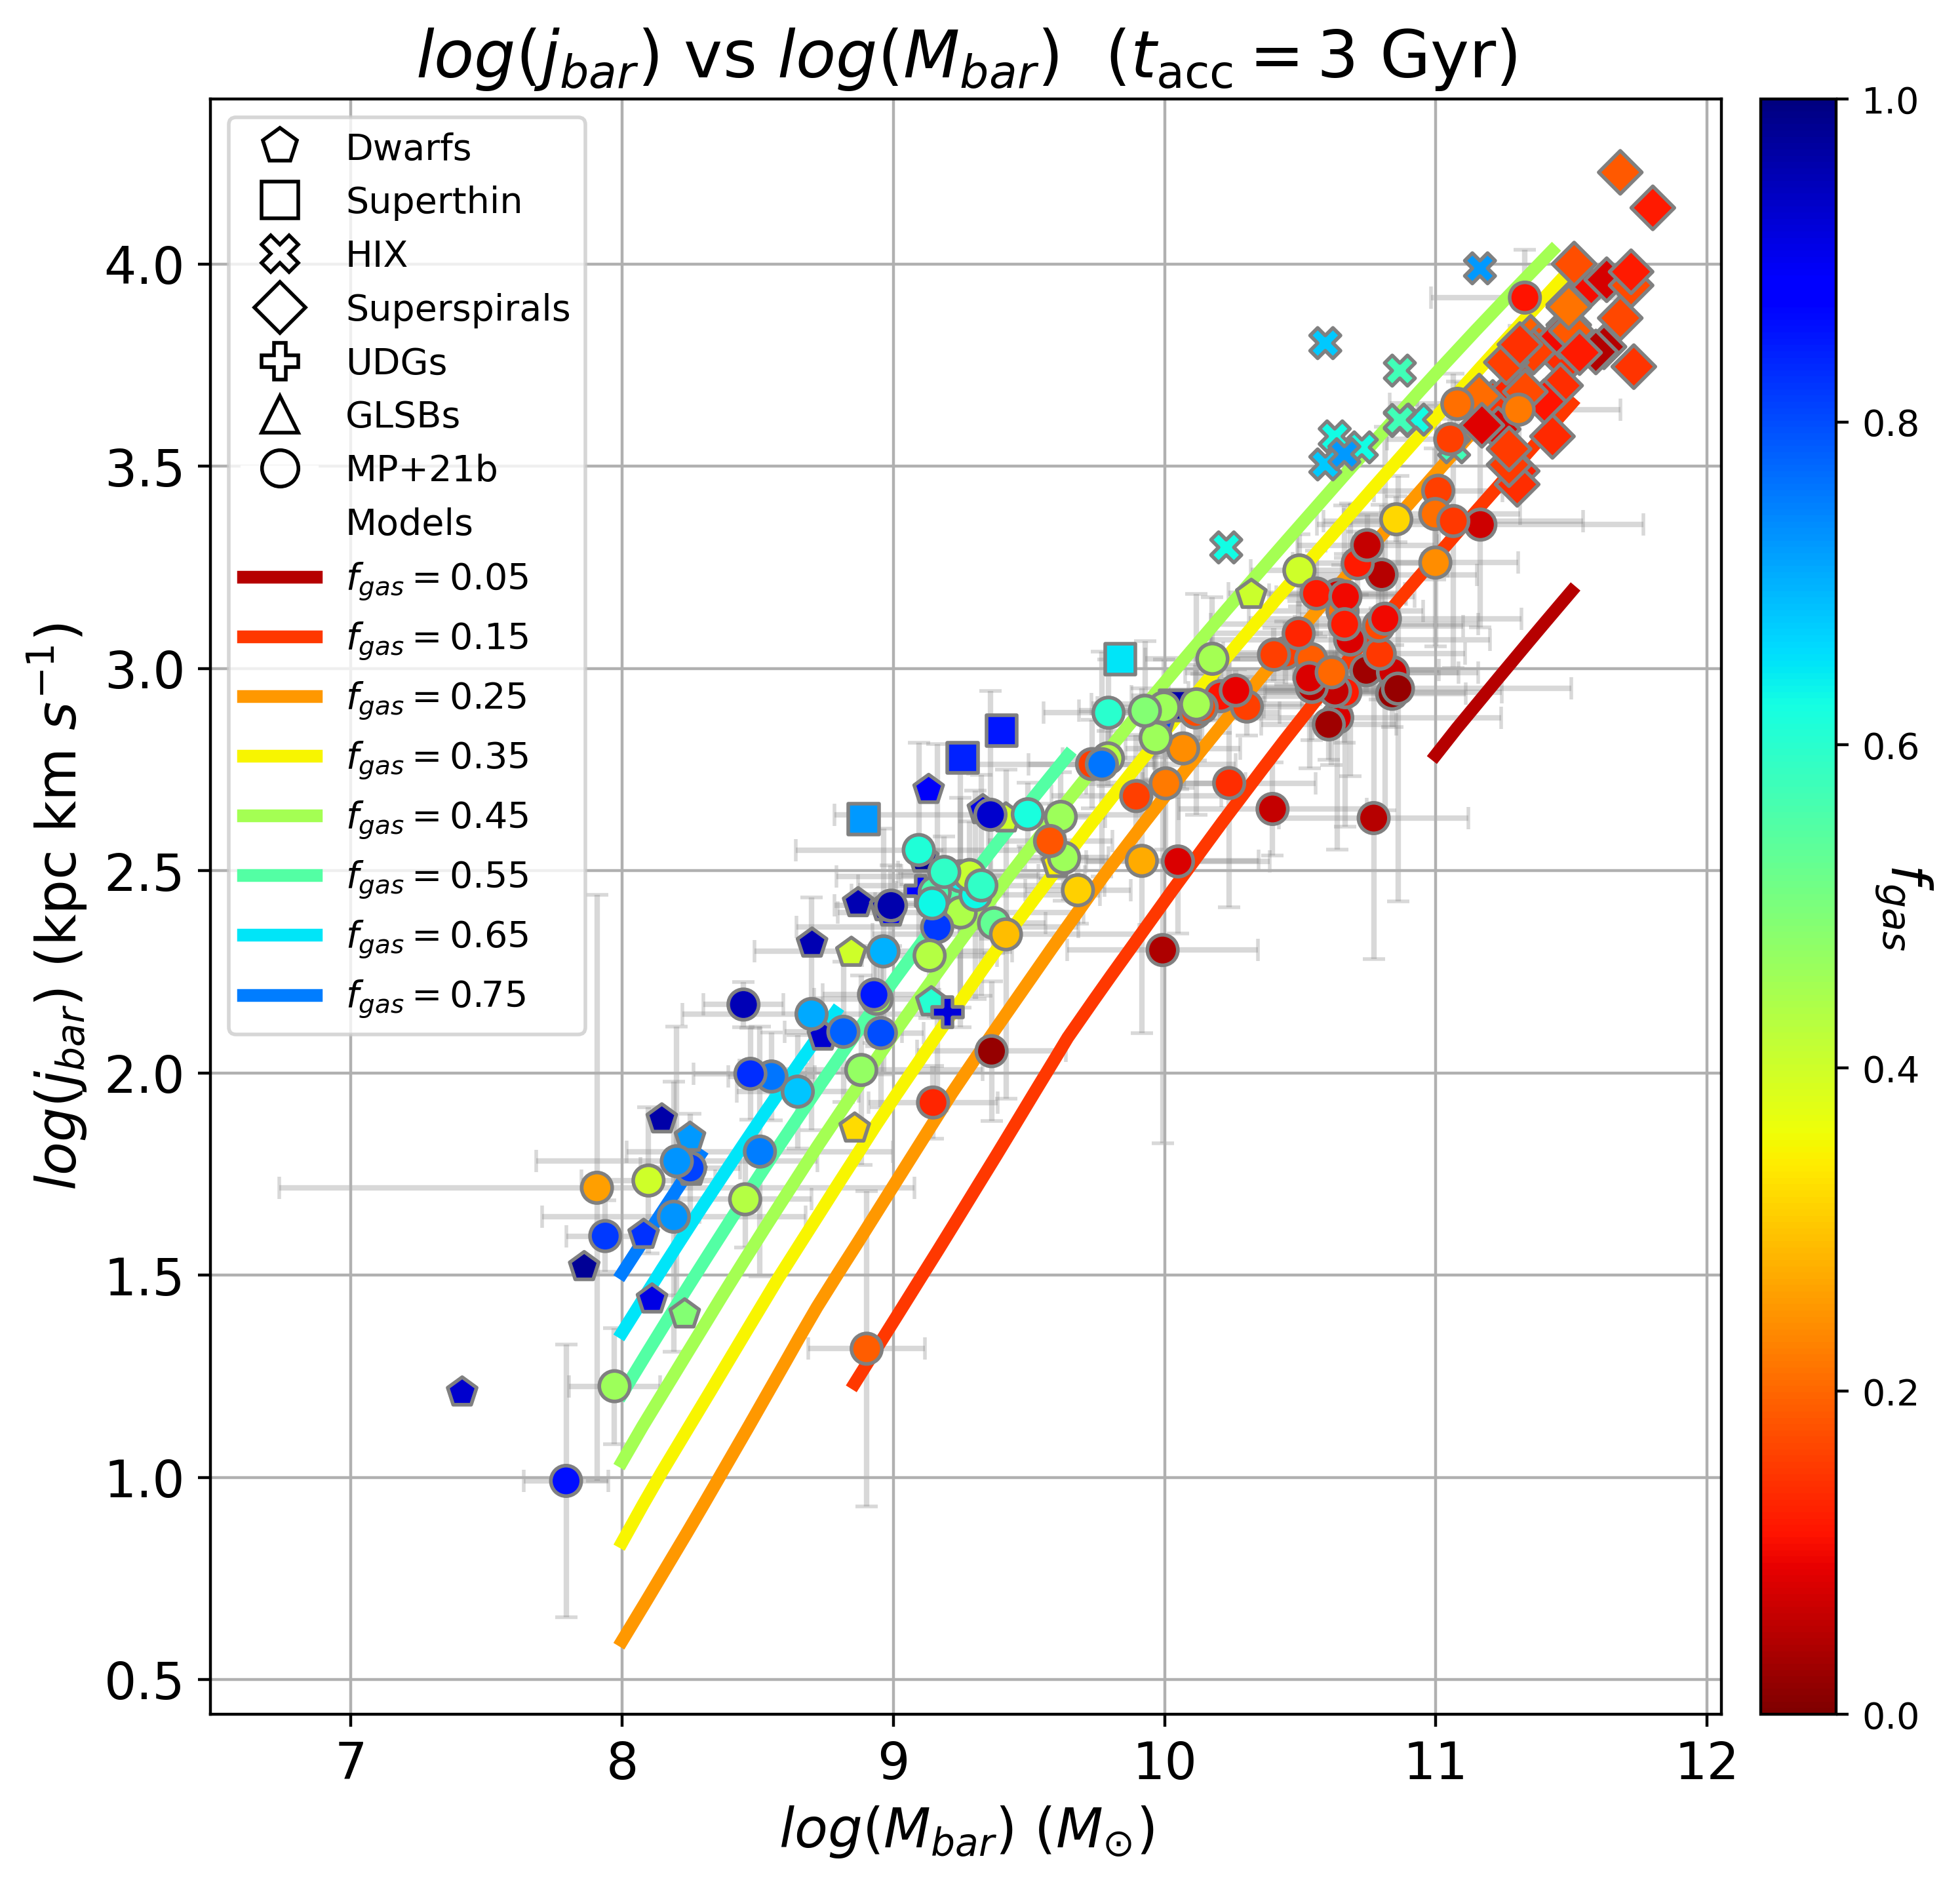

Execution time: 1.2658 seconds


In [27]:
log_j_bar_array_10_50 = np.log10(j_bar_array_10_50_cutoff_ksl)

cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = np.arange(0.05, 1.0, 0.1)
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 0, :].min(),f_gas_array_10_50_cutoff_ksl[i, 0, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 0, :], log_j_bar_array_10_50[i, 0, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$  ($t_{\mathrm{acc}} = 3$ Gyr)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).png')

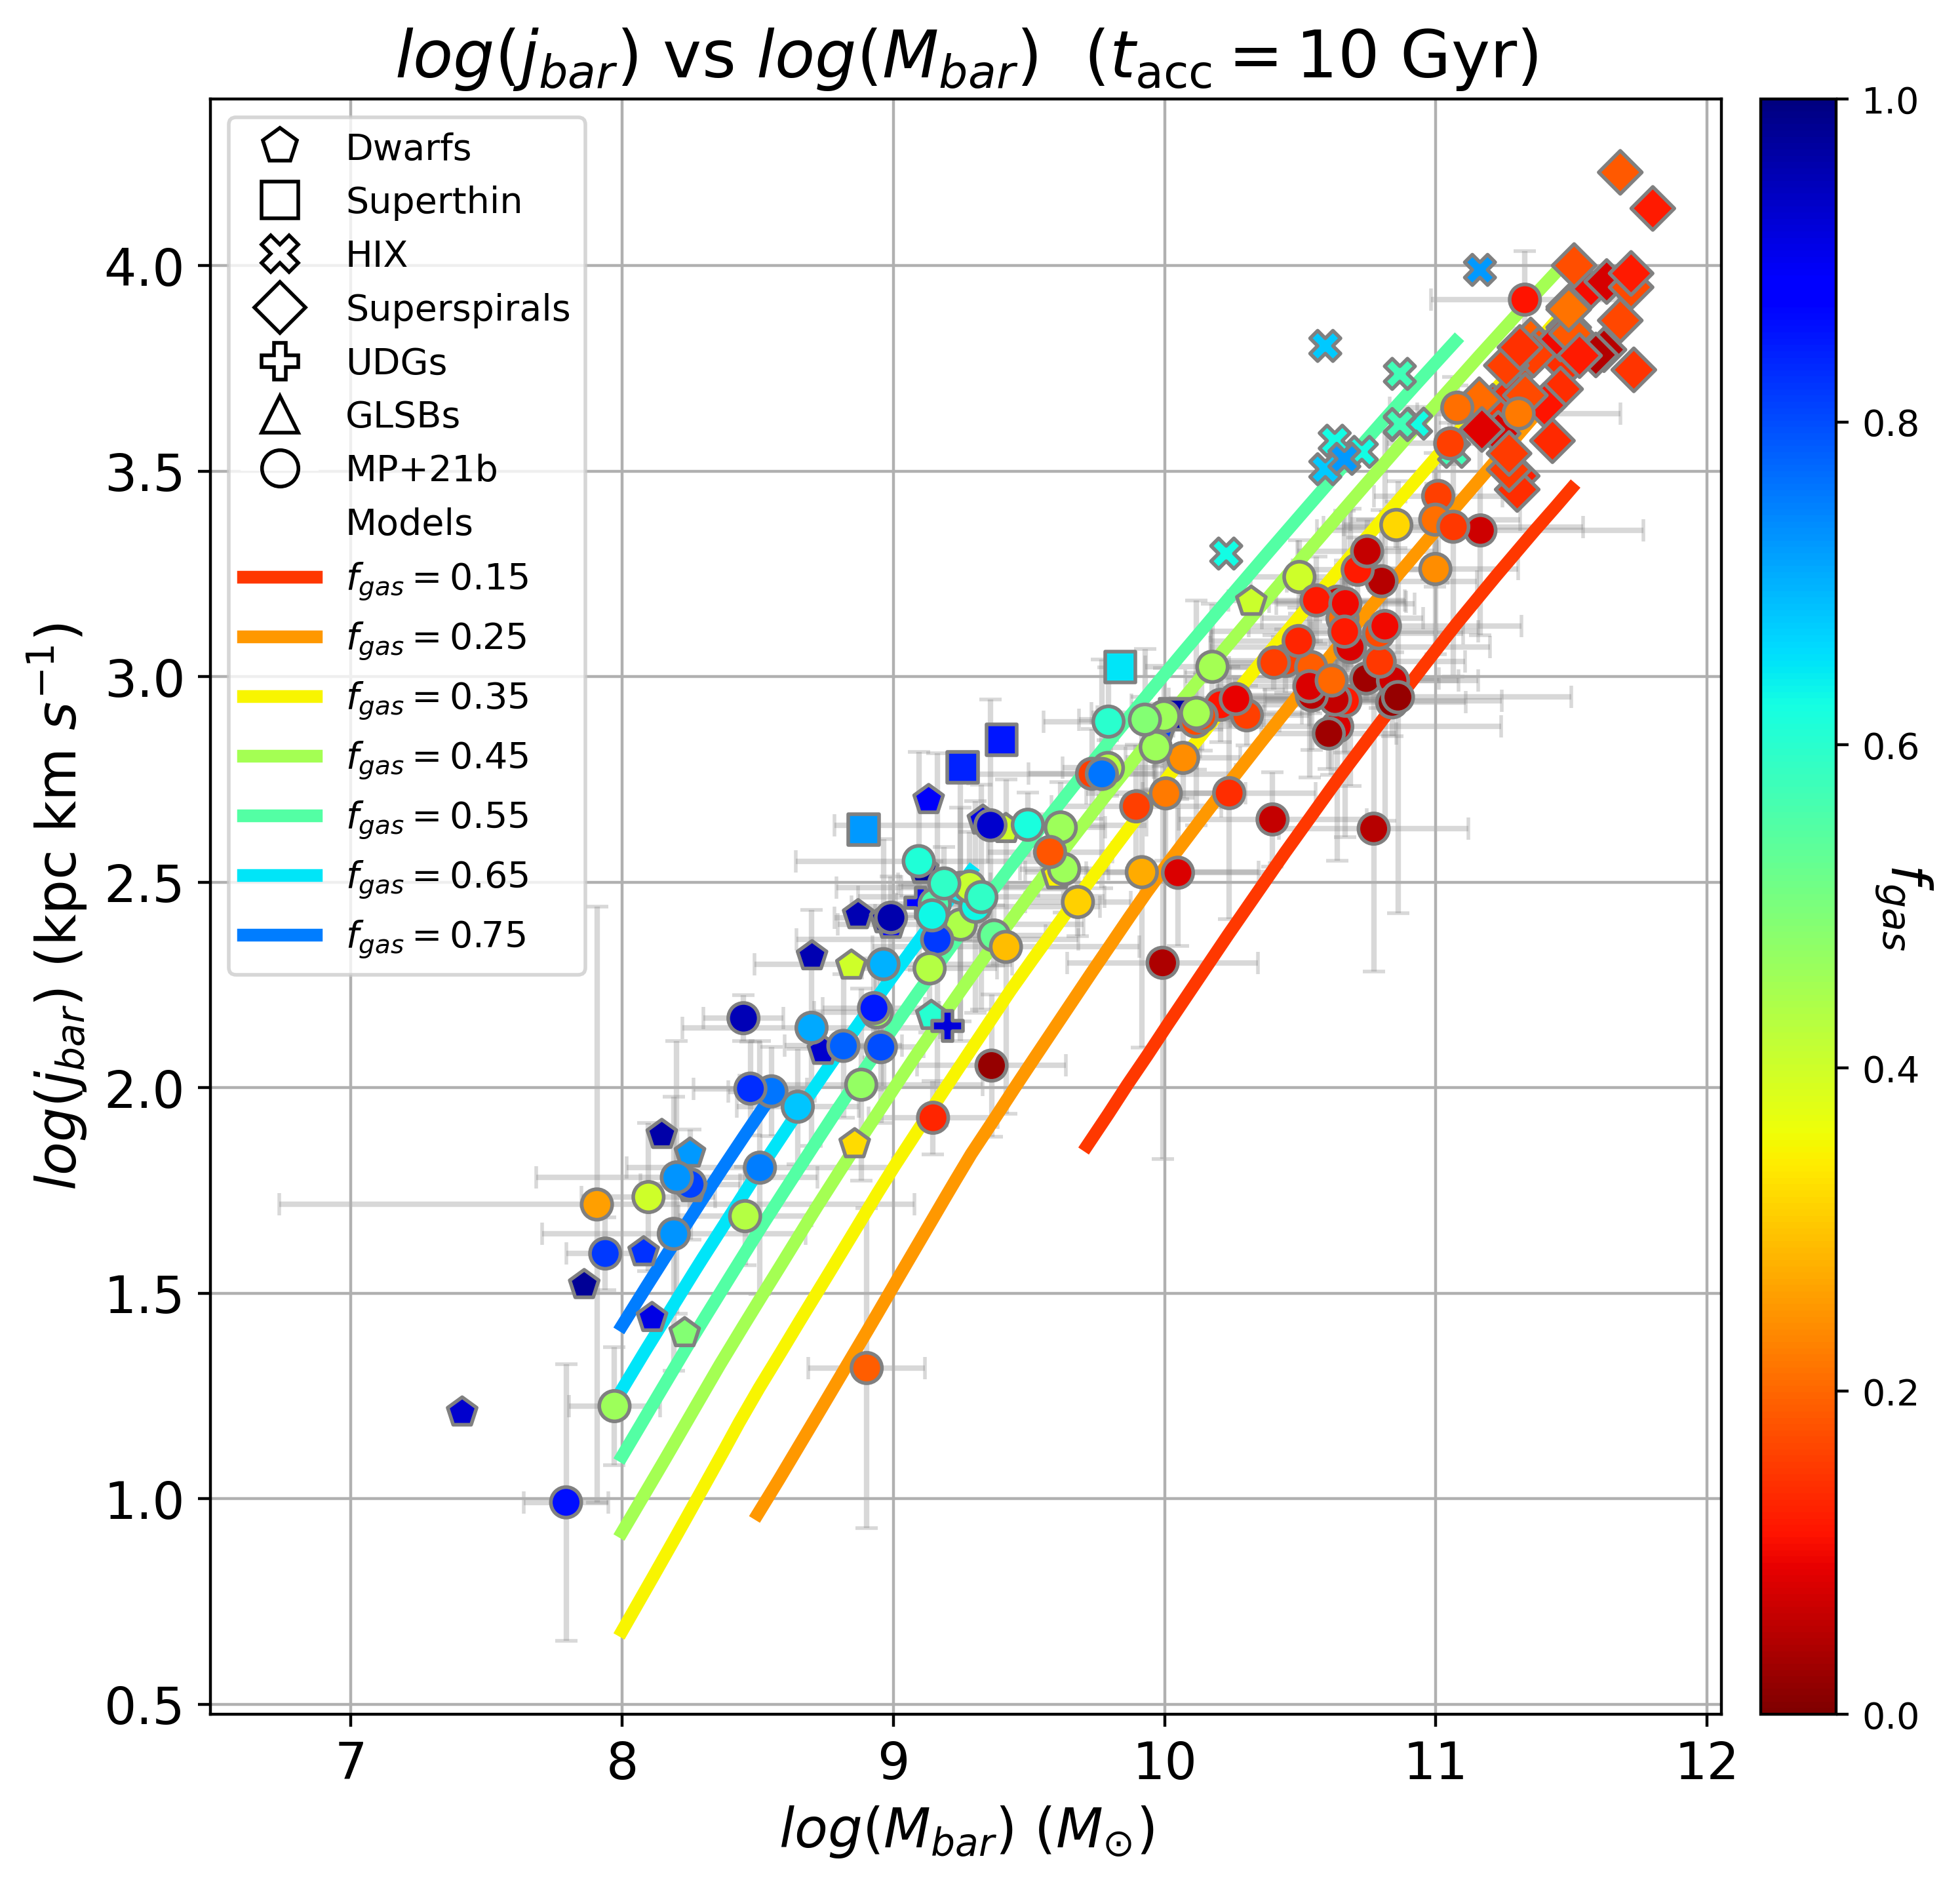

Execution time: 0.9473 seconds


In [28]:
cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = np.arange(0.05, 1.0, 0.1)
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 1, :].min(),f_gas_array_10_50_cutoff_ksl[i, 1, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 1, :], log_j_bar_array_10_50[i, 1, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$  ($t_{\mathrm{acc}} = 10$ Gyr)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).png')

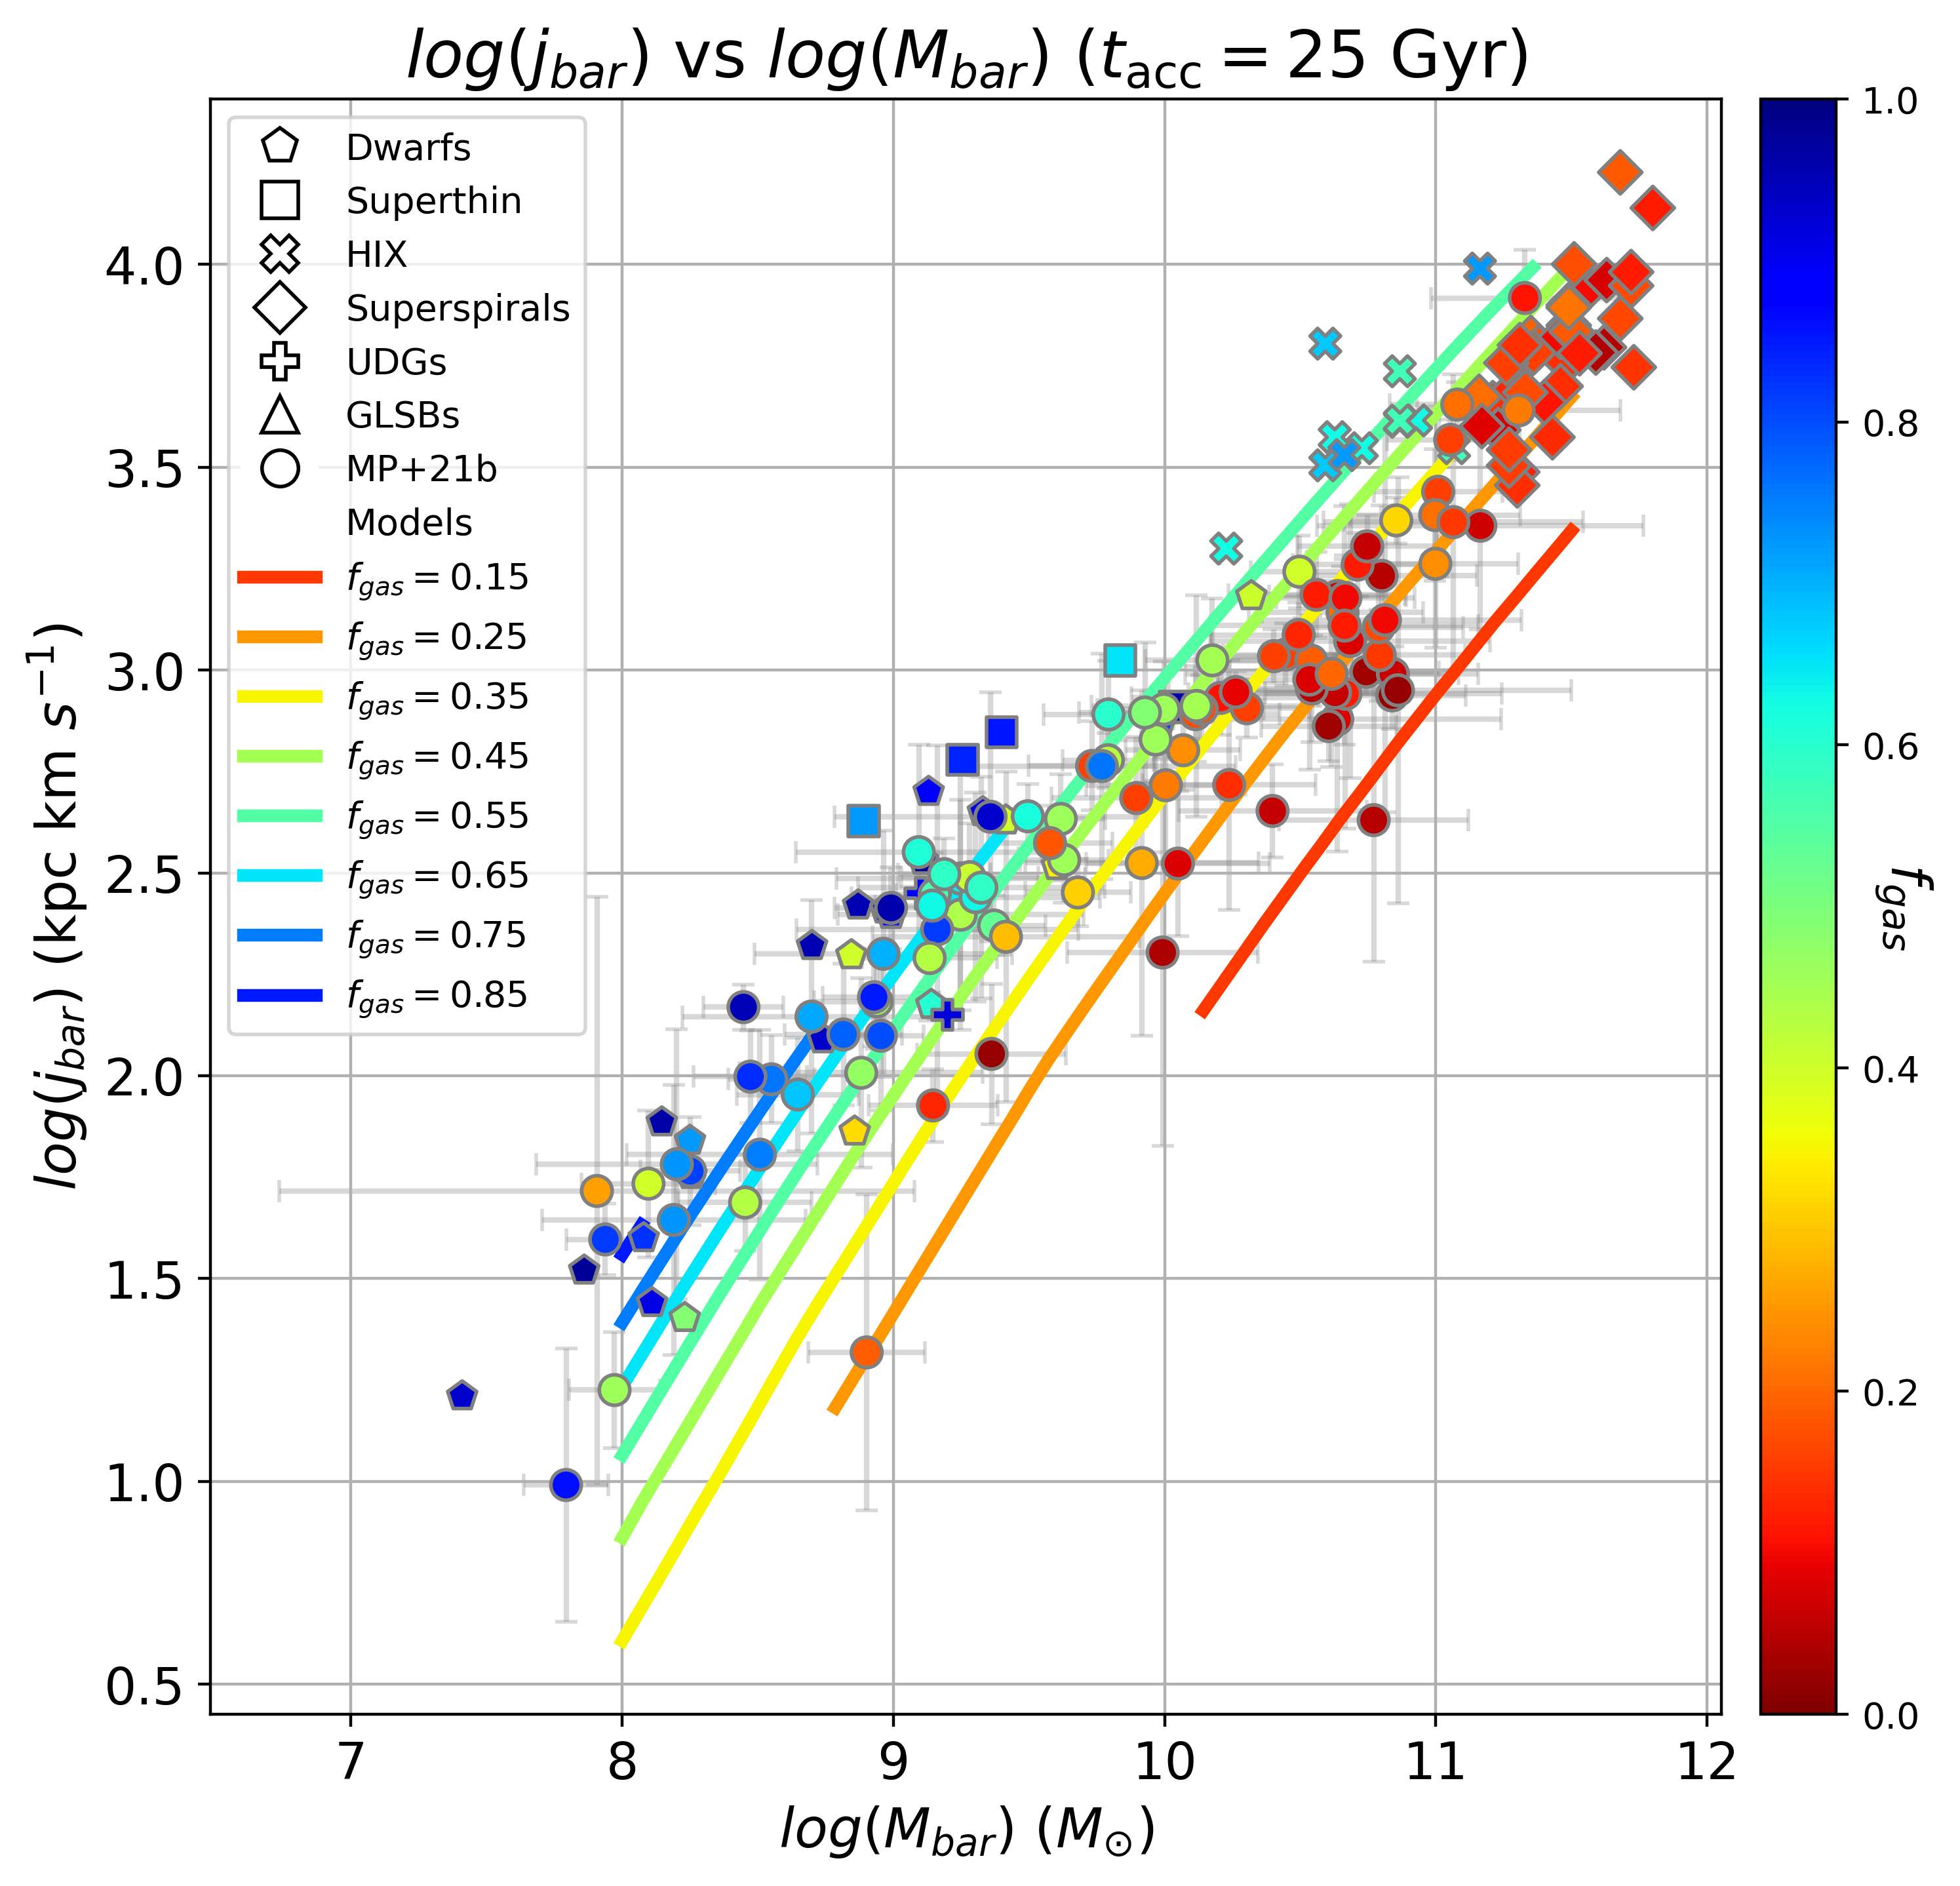

Execution time: 0.9637 seconds


In [29]:
cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = np.arange(0.05, 1.0, 0.1)
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 2, :].min(),f_gas_array_10_50_cutoff_ksl[i, 2, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 2, :], log_j_bar_array_10_50[i, 2, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$ ($t_{\mathrm{acc}} = 25$ Gyr)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).png')

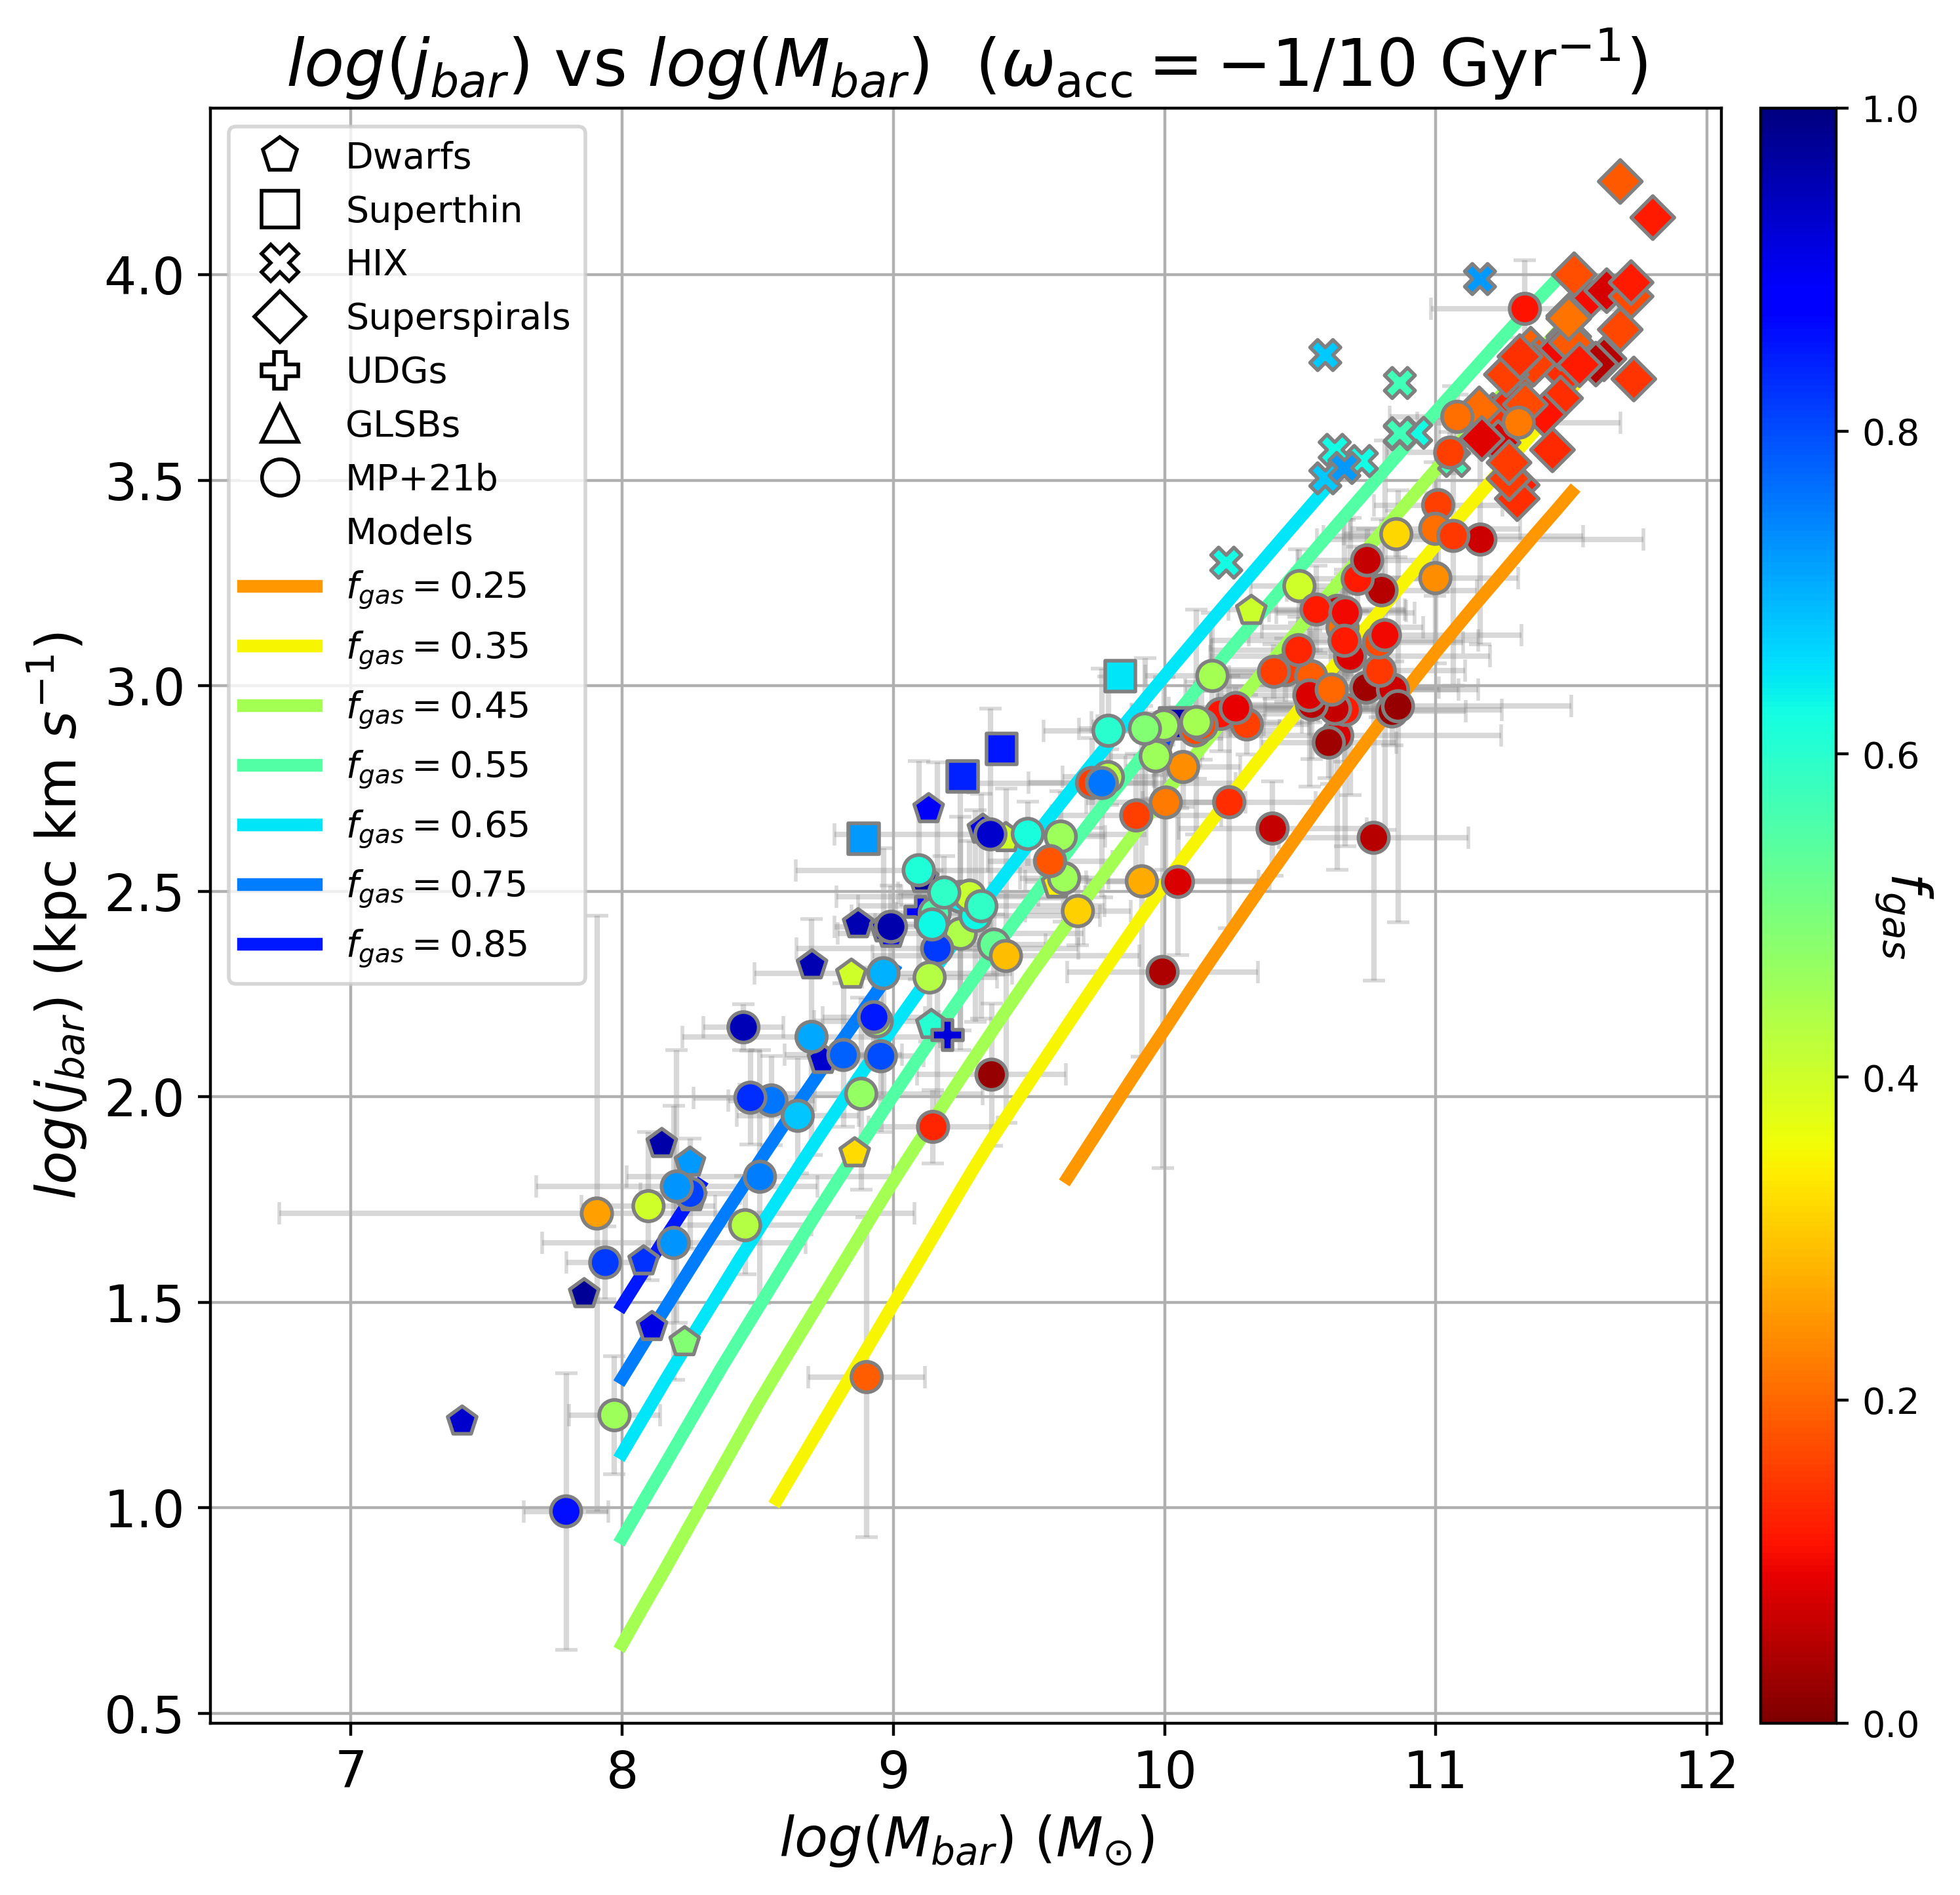

Execution time: 0.9518 seconds


In [30]:
log_j_bar_array_10_50 = np.log10(j_bar_array_10_50_cutoff_ksl)

cmap = cm.jet_r
mpl.rc("image", cmap="jet_r")
fig = figure(figsize=(8,8), dpi=400, facecolor='w')
frame = fig.add_subplot(1,1,1)

#Model
divider = make_axes_locatable(frame)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

mods = frame.plot([], [], ' ', label="Models")

f_gas_values = np.arange(0.05, 1.0, 0.1)
colors = cmap(f_gas_values)
ax1s = []

n=1000
interp_f_gas_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    interp_f_gas_array_10_50_cutoff_ksl[i] = np.linspace(f_gas_array_10_50_cutoff_ksl[i, 3, :].min(),f_gas_array_10_50_cutoff_ksl[i, 3, :].max(),n)

interp_j_bar_array_10_50_cutoff_ksl = np.zeros((len(log_M_bar_array),n))
for i,Mbar in enumerate(log_M_bar_array):
    ipl_10_50 = spl.interp1d(f_gas_array_10_50_cutoff_ksl[i, 3, :], log_j_bar_array_10_50[i, 3, :], kind='linear')
    interp_j_bar_array_10_50_cutoff_ksl[i] = ipl_10_50(interp_f_gas_array_10_50_cutoff_ksl[i])

for i,f_gas_value in enumerate(f_gas_values):
    indexed_M_array_lin, indexed_j_array = modelled_j_bar2(interp_f_gas_array_10_50_cutoff_ksl, interp_j_bar_array_10_50_cutoff_ksl, f_gas_value)
    ax1 = frame.plot(indexed_M_array_lin, indexed_j_array, label=r"$f_{gas} = $"+f"{f_gas_value:.2f}", color=colors[i], lw=3.5, zorder=2)
    ax1s.append(ax1[0])

valid_model_lines = []
for line in ax1s:
    x = line.get_xdata()
    y = line.get_ydata()
    if x.size > 0 and y.size > 0 and np.isfinite(x).any() and np.isfinite(y).any():
        valid_model_lines.append(line)

#Data
ax2 = frame.scatter(obs_Mbar, obs_jbar, label="MP+21b", marker="o", facecolors=cmap(BARY['fgas']), edgecolors="grey", s=70, zorder=9)
frame.errorbar(obs_Mbar, obs_jbar, xerr=obs_Mbar_errors, yerr=obs_jbar_errors, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
cbar = fig.colorbar(ax2, cax=colbarframe)
cbar.set_label(r"$f_{gas}$", rotation=270, fontsize=15)

markers = itertools.cycle(('p', 's', 'X', 'D', 'P', '^'))
names = itertools.cycle(('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
scatter_legends = []
for (idx, df), i in zip(pavel_data.items(), range(3,8)):
    marker = next(markers)
    name = next(names)
    scatter = frame.scatter(df['logMbar'], df['logjbar'], label=name, marker=marker, facecolors=cmap(df['fgas']), edgecolors="grey", s=70, zorder=i)
    scatter_legends.append(scatter)
    
scatter_legend_elements = [
    plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label=name)
    for marker, name in zip(('p', 's', 'X', 'D', 'P', '^'), ('Dwarfs', 'Superthin', 'HIX', 'Superspirals', 'UDGs', 'GLSBs'))
]
    
legend_elements = scatter_legend_elements + [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='k', markersize=10, label="MP+21b")] + mods + valid_model_lines

frame.set_title(r"$log(j_{bar})$ vs $log(M_{bar})$  ($\omega_{\mathrm{acc}} = -1/10$ Gyr$^{-1}$)", fontsize = 18)
frame.set_xlabel(r"$log(M_{bar})$ $(M_{\odot})$", fontsize = 15)
frame.set_ylabel(r"$log(j_{bar})$ (kpc km $s^{-1}$)", fontsize = 15)
frame.legend(handles=legend_elements)
frame.tick_params(labelsize=14)
frame.grid(zorder=1)
show()
# fig.savefig('../outputs/graphs_elise_new_rot/log j_bar vs log_M_bar with Pavel (interpolated, KSL).png')